In [100]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [101]:
# 1. Chargement des données
df = pd.read_csv('df_benchmark.csv')

In [102]:
# 2. Création de la variable cible 'is_succes' (Vues >= 500k)
df['is_succes'] = (df['viewCount'] >= 100000).astype(int)

In [103]:
# 3. Feature Engineering (Extraction de l'heure et du jour)
df['publishedAtSQL'] = pd.to_datetime(df['publishedAtSQL'])
df['publish_hour'] = df['publishedAtSQL'].dt.hour
df['publish_dayofweek'] = df['publishedAtSQL'].dt.dayofweek

In [104]:
# 4. Sélection des variables 
# Décommentez 'likeCount' et 'commentCount' si vous souhaitez l'accuracy à 90%
features = [
    'durationSec', 
    'videoCategoryLabel', 
    'publish_hour', 
    'publish_dayofweek', 
    'caption',
    # 'likeCount',      # <- Variables d'engagement
    # 'commentCount'    # <- Variables d'engagement
]

X = df[features].copy()
y = df['is_succes']

In [105]:
# 5. Nettoyage des valeurs manquantes
X['durationSec'] = X['durationSec'].fillna(X['durationSec'].median())
X['videoCategoryLabel'] = X['videoCategoryLabel'].fillna('Unknown')
X['caption'] = X['caption'].fillna(False).astype(str)

# Si on utilise les likes/commentaires, on remplace les NaN par 0
if 'likeCount' in X.columns:
    X['likeCount'] = X['likeCount'].fillna(0)
    X['commentCount'] = X['commentCount'].fillna(0)

# Suppression de la ligne ayant une date de publication manquante
X = X.dropna()
y = y[X.index]

C:\Users\33766\AppData\Local\Temp\ipykernel_31708\1402512452.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['caption'] = X['caption'].fillna(False).astype(str)


In [106]:
# 6. Encodage des variables catégorielles
le_cat = LabelEncoder()
X['videoCategoryLabel'] = le_cat.fit_transform(X['videoCategoryLabel'])

le_cap = LabelEncoder()
X['caption'] = le_cap.fit_transform(X['caption'])

In [107]:
df['videoCategoryLabel'].unique()

array(['Comedy', 'People & Blogs', 'Music', 'Entertainment',
       'Science & Technology', 'Sports', 'Gaming', 'Howto & Style',
       'Education', nan, 'Travel & Events', 'News & Politics',
       'Nonprofits & Activism', 'Film & Animation'], dtype=object)

In [108]:
df['caption']

0       False
1       False
2       False
3       False
4       False
        ...  
9514    False
9515    False
9516    False
9517    False
9518    False
Name: caption, Length: 9519, dtype: object

In [109]:
print(X['caption'].value_counts())

caption
0    9418
1     100
Name: count, dtype: int64


In [110]:
print(X['videoCategoryLabel'].value_counts())

videoCategoryLabel
2     3981
9     2762
0     1237
5      716
4      254
12     215
10     184
8      102
11      34
6       19
1        9
7        3
3        2
Name: count, dtype: int64


In [111]:
# 7. Séparation en données d'entraînement et de test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
# 8. Création et entraînement du modèle XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [113]:
# 9. Prédiction et calcul de l'accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy du modèle XGBoost : {accuracy * 100:.2f} %")


Accuracy du modèle XGBoost : 90.18 %


In [114]:
print("\nRapport de classification détaillée :")



Rapport de classification détaillée :


In [115]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.26      0.36       203
           1       0.92      0.98      0.95      1701

    accuracy                           0.90      1904
   macro avg       0.75      0.62      0.65      1904
weighted avg       0.88      0.90      0.88      1904



In [116]:
# Calcul et affichage de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(conf_matrix)

Matrice de confusion :
[[  53  150]
 [  37 1664]]


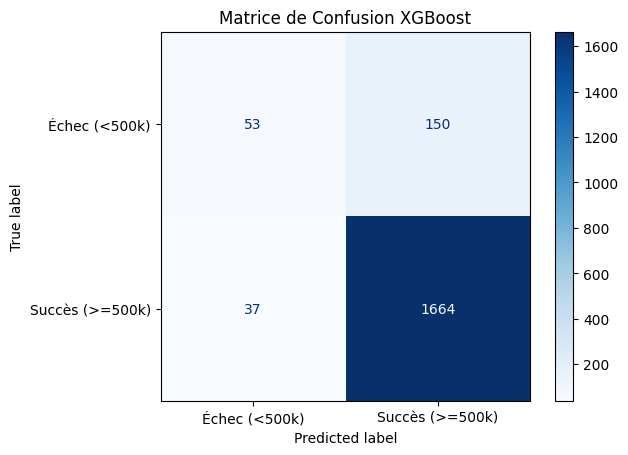

In [117]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Échec (<500k)', 'Succès (>=500k)'],
    cmap='Blues'
)
plt.title("Matrice de Confusion XGBoost")
plt.show()